# Vacuum executor benchmarks

This notebook compares the event-probability calculation speed in vacuum with and without the specialized executor.

The benchmark uses:
- a large fixed event sample
- several PMNS parameter points
- identical event inputs for both paths

The idea matches a fitter workflow: event kinematics stay fixed while PMNS parameters vary.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

try:
    import pandas as pd
except ImportError:
    pd = None

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import vacuum
from nu_waves.propagation.oscillator import NeutrinoEventBatch, Oscillator
import nu_waves.utils.flavors as flavors
import nu_waves.utils.style


## Shared helpers

In [2]:
def build_vacuum_oscillator(angles_deg, delta_cp_deg, dm2_21, dm2_32, useExecutor=True):
    angles = {
        (1, 2): np.deg2rad(angles_deg["theta12"]),
        (1, 3): np.deg2rad(angles_deg["theta13"]),
        (2, 3): np.deg2rad(angles_deg["theta23"]),
    }
    phases = {(1, 3): np.deg2rad(delta_cp_deg)}
    dm2 = {(2, 1): dm2_21, (3, 2): dm2_32}

    h = vacuum.Hamiltonian(
        mixing=Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases),
        spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2),
        antineutrino=False,
    )
    return Oscillator(hamiltonian=h, useExecutor=useExecutor)


def time_call(func, n_repeat=3):
    timings = []
    out = None
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        out = func()
        t1 = time.perf_counter()
        timings.append(t1 - t0)
    return out, np.array(timings)


## Fixed event sample

The event batch is intentionally heterogeneous: mixed channels and mixed neutrino / antineutrino flags.

In [3]:
rng = np.random.default_rng(42)

n_events_per_group = 150000
n_total_events = 4 * n_events_per_group
E_min, E_max = 0.2, 3.0
beam_grid = np.linspace(E_min, E_max, 1400)
beam_flux = (
    0.85 * np.exp(-0.5 * ((beam_grid - 0.62) / 0.16) ** 2)
    + 0.15 * np.exp(-0.5 * ((beam_grid - 1.15) / 0.35) ** 2)
)
beam_pdf = beam_flux / beam_flux.sum()

E_nu_true = rng.choice(beam_grid, size=n_events_per_group, p=beam_pdf)
L_true_km = np.full(n_events_per_group, 295.0)

event_batch = NeutrinoEventBatch(
    L_km=np.tile(L_true_km, 4),
    E_GeV=np.tile(E_nu_true, 4),
    flavor_emit=np.full(n_total_events, flavors.muon, dtype=int),
    flavor_det=np.concatenate([
        np.full(n_events_per_group, flavors.muon, dtype=int),
        np.full(n_events_per_group, flavors.electron, dtype=int),
        np.full(n_events_per_group, flavors.muon, dtype=int),
        np.full(n_events_per_group, flavors.electron, dtype=int),
    ]),
    isAntiNu=np.concatenate([
        np.full(2 * n_events_per_group, False, dtype=bool),
        np.full(2 * n_events_per_group, True, dtype=bool),
    ]),
)

print(f"Total number of events: {n_total_events}")


Total number of events: 600000


## PMNS points

A few representative parameter points are scanned to mimic repeated fitter evaluations.

In [4]:
pmns_points = [
    {
        "label": "NO nominal",
        "angles": {"theta12": 33.4, "theta13": 8.6, "theta23": 49.0},
        "delta_cp_deg": 195.0,
        "dm2_21": 7.42e-5,
        "dm2_32": 2.4428e-3,
    },
    {
        "label": "delta shifted",
        "angles": {"theta12": 33.4, "theta13": 8.6, "theta23": 49.0},
        "delta_cp_deg": 240.0,
        "dm2_21": 7.42e-5,
        "dm2_32": 2.4428e-3,
    },
    {
        "label": "theta23 low",
        "angles": {"theta12": 33.4, "theta13": 8.6, "theta23": 45.0},
        "delta_cp_deg": 195.0,
        "dm2_21": 7.42e-5,
        "dm2_32": 2.4428e-3,
    },
    {
        "label": "theta13 high",
        "angles": {"theta12": 33.4, "theta13": 8.9, "theta23": 49.0},
        "delta_cp_deg": 195.0,
        "dm2_21": 7.42e-5,
        "dm2_32": 2.4428e-3,
    },
    {
        "label": "IO-like",
        "angles": {"theta12": 33.4, "theta13": 8.6, "theta23": 49.0},
        "delta_cp_deg": 195.0,
        "dm2_21": 7.42e-5,
        "dm2_32": -2.4428e-3,
    },
]

pmns_rows = [{k: v for k, v in point.items() if k != 'angles'} for point in pmns_points]
if pd is not None:
    pd.DataFrame(pmns_rows)
else:
    pmns_rows


## Batch compilation cost

In [5]:
osc_compile = build_vacuum_oscillator(
    angles_deg=pmns_points[0]["angles"],
    delta_cp_deg=pmns_points[0]["delta_cp_deg"],
    dm2_21=pmns_points[0]["dm2_21"],
    dm2_32=pmns_points[0]["dm2_32"],
    useExecutor=True,
)

compiled_batch, compile_timings = time_call(lambda: osc_compile.compileEvents(event_batch), n_repeat=3)
print(f"Compilation time: {compile_timings.mean():.4f} +- {compile_timings.std():.4f} s")
print(f"Number of compiled groups: {len(compiled_batch.groups)}")


Compilation time: 0.3190 +- 0.0020 s
Number of compiled groups: 4


## Event-batch benchmark

This compares the public event-batch API directly, without precompiling.

In [6]:
rows_event_batch = []
reference_probabilities = None

for point in pmns_points:
    osc_executor = build_vacuum_oscillator(
        angles_deg=point["angles"],
        delta_cp_deg=point["delta_cp_deg"],
        dm2_21=point["dm2_21"],
        dm2_32=point["dm2_32"],
        useExecutor=True,
    )
    osc_legacy = build_vacuum_oscillator(
        angles_deg=point["angles"],
        delta_cp_deg=point["delta_cp_deg"],
        dm2_21=point["dm2_21"],
        dm2_32=point["dm2_32"],
        useExecutor=False,
    )

    P_executor, t_executor = time_call(lambda: osc_executor.probability(event_batch), n_repeat=3)
    P_legacy, t_legacy = time_call(lambda: osc_legacy.probability(event_batch), n_repeat=3)

    np.testing.assert_allclose(P_executor, P_legacy, atol=1e-12)
    if reference_probabilities is None:
        reference_probabilities = P_executor

    rows_event_batch.append({
        "point": point["label"],
        "executor_mean_s": t_executor.mean(),
        "legacy_mean_s": t_legacy.mean(),
        "speedup": t_legacy.mean() / t_executor.mean(),
    })

if pd is not None:
    df_event_batch = pd.DataFrame(rows_event_batch)
    df_event_batch
else:
    df_event_batch = rows_event_batch
    df_event_batch


## Compiled-batch benchmark

This isolates the repeated fitter-like evaluation cost after a one-time compilation.

In [7]:
rows_compiled = []

for point in pmns_points:
    osc_executor = build_vacuum_oscillator(
        angles_deg=point["angles"],
        delta_cp_deg=point["delta_cp_deg"],
        dm2_21=point["dm2_21"],
        dm2_32=point["dm2_32"],
        useExecutor=True,
    )
    osc_legacy = build_vacuum_oscillator(
        angles_deg=point["angles"],
        delta_cp_deg=point["delta_cp_deg"],
        dm2_21=point["dm2_21"],
        dm2_32=point["dm2_32"],
        useExecutor=False,
    )

    compiled_executor = osc_executor.compileEvents(event_batch)
    compiled_legacy = osc_legacy.compileEvents(event_batch)

    P_executor, t_executor = time_call(lambda: osc_executor.probability(compiled_executor), n_repeat=3)
    P_legacy, t_legacy = time_call(lambda: osc_legacy.probability(compiled_legacy), n_repeat=3)

    np.testing.assert_allclose(P_executor, P_legacy, atol=1e-12)
    rows_compiled.append({
        "point": point["label"],
        "executor_mean_s": t_executor.mean(),
        "legacy_mean_s": t_legacy.mean(),
        "speedup": t_legacy.mean() / t_executor.mean(),
    })

if pd is not None:
    df_compiled = pd.DataFrame(rows_compiled)
    df_compiled
else:
    df_compiled = rows_compiled
    df_compiled


## Visual summary

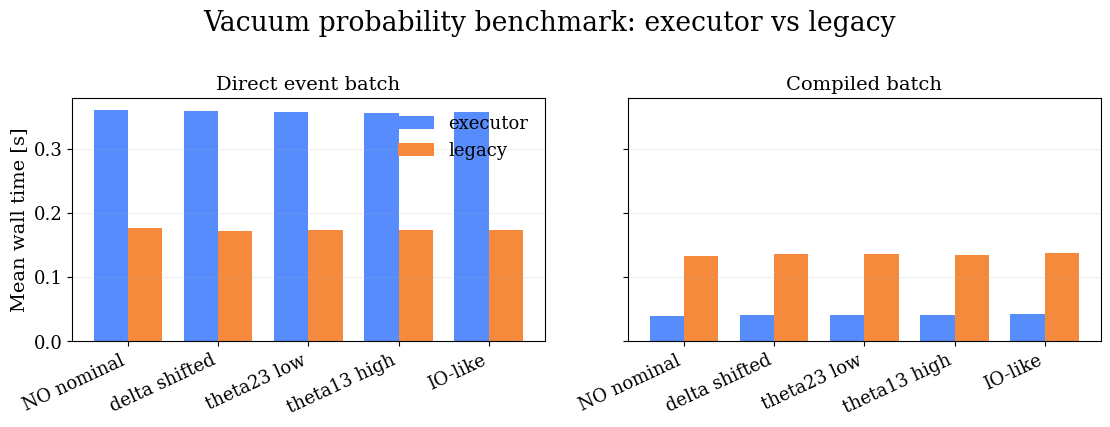

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)

event_points = df_event_batch["point"] if pd is not None else [row["point"] for row in df_event_batch]
event_executor = df_event_batch["executor_mean_s"] if pd is not None else [row["executor_mean_s"] for row in df_event_batch]
event_legacy = df_event_batch["legacy_mean_s"] if pd is not None else [row["legacy_mean_s"] for row in df_event_batch]
compiled_points = df_compiled["point"] if pd is not None else [row["point"] for row in df_compiled]
compiled_executor = df_compiled["executor_mean_s"] if pd is not None else [row["executor_mean_s"] for row in df_compiled]
compiled_legacy = df_compiled["legacy_mean_s"] if pd is not None else [row["legacy_mean_s"] for row in df_compiled]

x = np.arange(len(event_points))
width = 0.38

axs[0].bar(x - width / 2, event_executor, width=width, label="executor")
axs[0].bar(x + width / 2, event_legacy, width=width, label="legacy")
axs[0].set_xticks(x)
axs[0].set_xticklabels(event_points, rotation=25, ha="right")
axs[0].set_title("Direct event batch")
axs[0].set_ylabel("Mean wall time [s]")
axs[0].grid(True, axis="y", alpha=0.3)
axs[0].legend(frameon=False)

axs[1].bar(x - width / 2, compiled_executor, width=width, label="executor")
axs[1].bar(x + width / 2, compiled_legacy, width=width, label="legacy")
axs[1].set_xticks(x)
axs[1].set_xticklabels(compiled_points, rotation=25, ha="right")
axs[1].set_title("Compiled batch")
axs[1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Vacuum probability benchmark: executor vs legacy")
fig.tight_layout()
plt.show()


## Speedup table

In [9]:
if pd is not None:
    df_summary = df_event_batch[["point", "speedup"]].rename(columns={"speedup": "event_batch_speedup"}).merge(
        df_compiled[["point", "speedup"]].rename(columns={"speedup": "compiled_batch_speedup"}),
        on="point",
    )
    df_summary
else:
    df_summary = [
        {
            "point": event_row["point"],
            "event_batch_speedup": event_row["speedup"],
            "compiled_batch_speedup": compiled_row["speedup"],
        }
        for event_row, compiled_row in zip(df_event_batch, df_compiled)
    ]
    df_summary
